## Generates the final tables and figures reported in the manuscript.

In [ ]:
!pip install simglucose==0.2.11

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.8/157.8 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.7 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.9.4-py3-none-any.whl size=215456 sha256=941b11d18cce3c83d89ca139a8d77e56d34e82cf8b84cdae049b0d34f397cb77
  Stored in directory: /root/.cache/pip/wheels/f9/12/86/011b8ba7c0f38ccbb5e524459c3d57cbd35bd8df9035fcdd4f
Successfully built gym
  Attempting uninstall: gymnasium
    Found existing

In [ ]:
!pip install simglucose==0.2.11 gym==0.23.1 pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
INFO: pip is looking at multiple versions of simglucose to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install gym==0.23.1 and simglucose==0.2.11 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested gym==0.23.1
    simglucose 0.2.11 depends on gym==0.9.4

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [ ]:
# CELL 1 — Setup
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import os
import numpy as np
import pandas as pd

RESULTS_DIR = "/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results"

files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith(".npy")])

print("Current directory:", os.getcwd())
print("Results dir exists:", os.path.exists(RESULTS_DIR))
print("NPY files found:", len(files))
print(files)

Mounted at /content/drive
/content/drive/MyDrive/Research/glycemic-hybrid-ga
Current directory: /content/drive/MyDrive/Research/glycemic-hybrid-ga
Results dir exists: True
NPY files found: 36
['G_S1_normal_ga_only.npy', 'G_S1_normal_ga_rules.npy', 'G_S1_normal_ga_surrogate.npy', 'G_S1_normal_hybrid.npy', 'G_S2_fasting_ga_only.npy', 'G_S2_fasting_ga_rules.npy', 'G_S2_fasting_ga_surrogate.npy', 'G_S2_fasting_hybrid.npy', 'G_S2_ramadan_ga_only.npy', 'G_S2_ramadan_ga_rules.npy', 'G_S2_ramadan_ga_surrogate.npy', 'G_S2_ramadan_hybrid.npy', 'G_S3_highcarb_ga_only.npy', 'G_S3_highcarb_ga_rules.npy', 'G_S3_highcarb_ga_surrogate.npy', 'G_S3_highcarb_hybrid.npy', 'G_S4_lowcarb_activity_ga_only.npy', 'G_S4_lowcarb_activity_ga_rules.npy', 'G_S4_lowcarb_activity_ga_surrogate.npy', 'G_S4_lowcarb_activity_hybrid.npy', 'best_history_S1_normal_ga_only.npy', 'best_history_S1_normal_ga_rules.npy', 'best_history_S1_normal_ga_surrogate.npy', 'best_history_S1_normal_hybrid.npy', 'glucose_S1_normal_ga_only.np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 1. Charger les résultats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/results/summary_all.csv")
df

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,...,DatasetSize,AUCsum,AUCmean,AUCregret,Backend,PatientName,TopKRealEval,RandomRealEval,Rho,Alpha
0,S1_normal,ga_only,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,1200,2889.517492,96.317250,0.366872,simglucose,adult#001,-1,-1,0.4,0.05
1,S1_normal,ga_rules,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,1200,2888.430544,96.281018,1.453819,simglucose,adult#001,-1,-1,0.4,0.05
2,S1_normal,ga_surrogate,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,552,2889.264489,96.308816,0.619875,simglucose,adult#001,-1,-1,0.4,0.05
3,S1_normal,hybrid,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,376,2888.328726,96.277624,1.555637,simglucose,adult#001,6,2,0.4,0.05
4,S2_fasting,ga_only,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,1200,2894.880318,96.496011,2.958400,simglucose,adult#002,-1,-1,0.4,0.05
5,S2_fasting,ga_rules,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,1200,2897.587730,96.586258,0.250988,simglucose,adult#002,-1,-1,0.4,0.05
6,S2_fasting,ga_surrogate,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,552,2896.161902,96.538730,1.676816,simglucose,adult#002,-1,-1,0.4,0.05
7,S2_fasting,hybrid,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,351,2888.416512,96.280550,9.422206,simglucose,adult#002,6,2,0.4,0.05
8,S3_highcarb,ga_only,-225.923997,-225.923997,92.517007,7.482993,0.0,9.708162,201.839871,144.914248,...,1200,6815.396308,227.179877,0.000000,simglucose,adolescent#001,-1,-1,0.4,0.05
9,S3_highcarb,ga_rules,-425.844836,-425.844836,92.517007,7.482993,0.0,9.933201,197.317616,143.452309,...,1200,12781.435197,426.047840,0.000000,simglucose,adolescent#001,-1,-1,0.4,0.05


In [ ]:
#2. Ajouter réduction des simulations
baseline = df[df["Method"] == "ga_only"][["Scenario", "SimCalls"]]
baseline = baseline.rename(columns={"SimCalls": "GAOnlyCalls"})

df2 = df.merge(baseline, on="Scenario")
df2["ReductionPct"] = 100 * (1 - df2["SimCalls"] / df2["GAOnlyCalls"])

df2.to_csv("outputs/results/summary_all_with_reduction.csv", index=False)
df2

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,...,AUCmean,AUCregret,Backend,PatientName,TopKRealEval,RandomRealEval,Rho,Alpha,GAOnlyCalls,ReductionPct
0,S1_normal,ga_only,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,96.317250,0.366872,simglucose,adult#001,-1,-1,0.4,0.05,1200,0.000000
1,S1_normal,ga_rules,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,96.281018,1.453819,simglucose,adult#001,-1,-1,0.4,0.05,1200,0.000000
2,S1_normal,ga_surrogate,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,96.308816,0.619875,simglucose,adult#001,-1,-1,0.4,0.05,1200,54.000000
3,S1_normal,hybrid,96.329479,96.329479,100.000000,0.000000,0.0,97.277581,176.199235,144.414815,...,96.277624,1.555637,simglucose,adult#001,6,2,0.4,0.05,1200,68.666667
4,S2_fasting,ga_only,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,96.496011,2.958400,simglucose,adult#002,-1,-1,0.4,0.05,1200,0.000000
5,S2_fasting,ga_rules,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,96.586258,0.250988,simglucose,adult#002,-1,-1,0.4,0.05,1200,0.000000
6,S2_fasting,ga_surrogate,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,96.538730,1.676816,simglucose,adult#002,-1,-1,0.4,0.05,1200,54.000000
7,S2_fasting,hybrid,96.594624,96.594624,100.000000,0.000000,0.0,90.519129,186.995628,159.059299,...,96.280550,9.422206,simglucose,adult#002,6,2,0.4,0.05,1200,70.750000
8,S3_highcarb,ga_only,-225.923997,-225.923997,92.517007,7.482993,0.0,9.708162,201.839871,144.914248,...,227.179877,0.000000,simglucose,adolescent#001,-1,-1,0.4,0.05,1200,0.000000
9,S3_highcarb,ga_rules,-425.844836,-425.844836,92.517007,7.482993,0.0,9.933201,197.317616,143.452309,...,426.047840,0.000000,simglucose,adolescent#001,-1,-1,0.4,0.05,1200,0.000000


In [ ]:
#3. Tableau principal pour le papier
table_main = df2[
    [
        "Scenario", "Method", "Fitness", "TIR", "TBR", "TAR",
        "Gmin", "Gmax", "SimCalls", "ReductionPct", "AUCmean", "AUCregret"
    ]
].copy()

table_main = table_main.round({
    "Fitness": 2,
    "TIR": 1,
    "TBR": 1,
    "TAR": 1,
    "Gmin": 1,
    "Gmax": 1,
    "ReductionPct": 1,
    "AUCmean": 2,
    "AUCregret": 2,
})

table_main.to_csv("outputs/results/table_main_paper.csv", index=False)
table_main

,Scenario,Method,Fitness,TIR,TBR,TAR,Gmin,Gmax,SimCalls,ReductionPct,AUCmean,AUCregret
0,S1_normal,ga_only,96.33,100.0,0.0,0.0,97.3,176.2,1200,0.0,96.32,0.37
1,S1_normal,ga_rules,96.33,100.0,0.0,0.0,97.3,176.2,1200,0.0,96.28,1.45
2,S1_normal,ga_surrogate,96.33,100.0,0.0,0.0,97.3,176.2,552,54.0,96.31,0.62
3,S1_normal,hybrid,96.33,100.0,0.0,0.0,97.3,176.2,376,68.7,96.28,1.56
4,S2_fasting,ga_only,96.59,100.0,0.0,0.0,90.5,187.0,1200,0.0,96.50,2.96
5,S2_fasting,ga_rules,96.59,100.0,0.0,0.0,90.5,187.0,1200,0.0,96.59,0.25
6,S2_fasting,ga_surrogate,96.59,100.0,0.0,0.0,90.5,187.0,552,54.0,96.54,1.68
7,S2_fasting,hybrid,96.59,100.0,0.0,0.0,90.5,187.0,351,70.8,96.28,9.42
8,S3_highcarb,ga_only,-225.92,92.5,7.5,0.0,9.7,201.8,1200,0.0,227.18,0.00
9,S3_highcarb,ga_rules,-425.84,92.5,7.5,0.0,9.9,197.3,1200,0.0,426.05,0.00


In [ ]:
#4. Tableau LaTeX
latex_table = table_main.to_latex(index=False, escape=False)
print(latex_table)

with open("outputs/results/table_main_paper.tex", "w") as f:
    f.write(latex_table)

\begin{tabular}{llrrrrrrrrrr}
\toprule
Scenario & Method & Fitness & TIR & TBR & TAR & Gmin & Gmax & SimCalls & ReductionPct & AUCmean & AUCregret \\
\midrule
S1_normal & ga_only & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 97.300000 & 176.200000 & 1200 & 0.000000 & 96.320000 & 0.370000 \\
S1_normal & ga_rules & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 97.300000 & 176.200000 & 1200 & 0.000000 & 96.280000 & 1.450000 \\
S1_normal & ga_surrogate & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 97.300000 & 176.200000 & 552 & 54.000000 & 96.310000 & 0.620000 \\
S1_normal & hybrid & 96.330000 & 100.000000 & 0.000000 & 0.000000 & 97.300000 & 176.200000 & 376 & 68.700000 & 96.280000 & 1.560000 \\
S2_fasting & ga_only & 96.590000 & 100.000000 & 0.000000 & 0.000000 & 90.500000 & 187.000000 & 1200 & 0.000000 & 96.500000 & 2.960000 \\
S2_fasting & ga_rules & 96.590000 & 100.000000 & 0.000000 & 0.000000 & 90.500000 & 187.000000 & 1200 & 0.000000 & 96.590000 & 0.250000 \\
S2_fasting & ga_s

In [ ]:
#1. Style global IEEE
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "lines.linewidth": 2.2,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

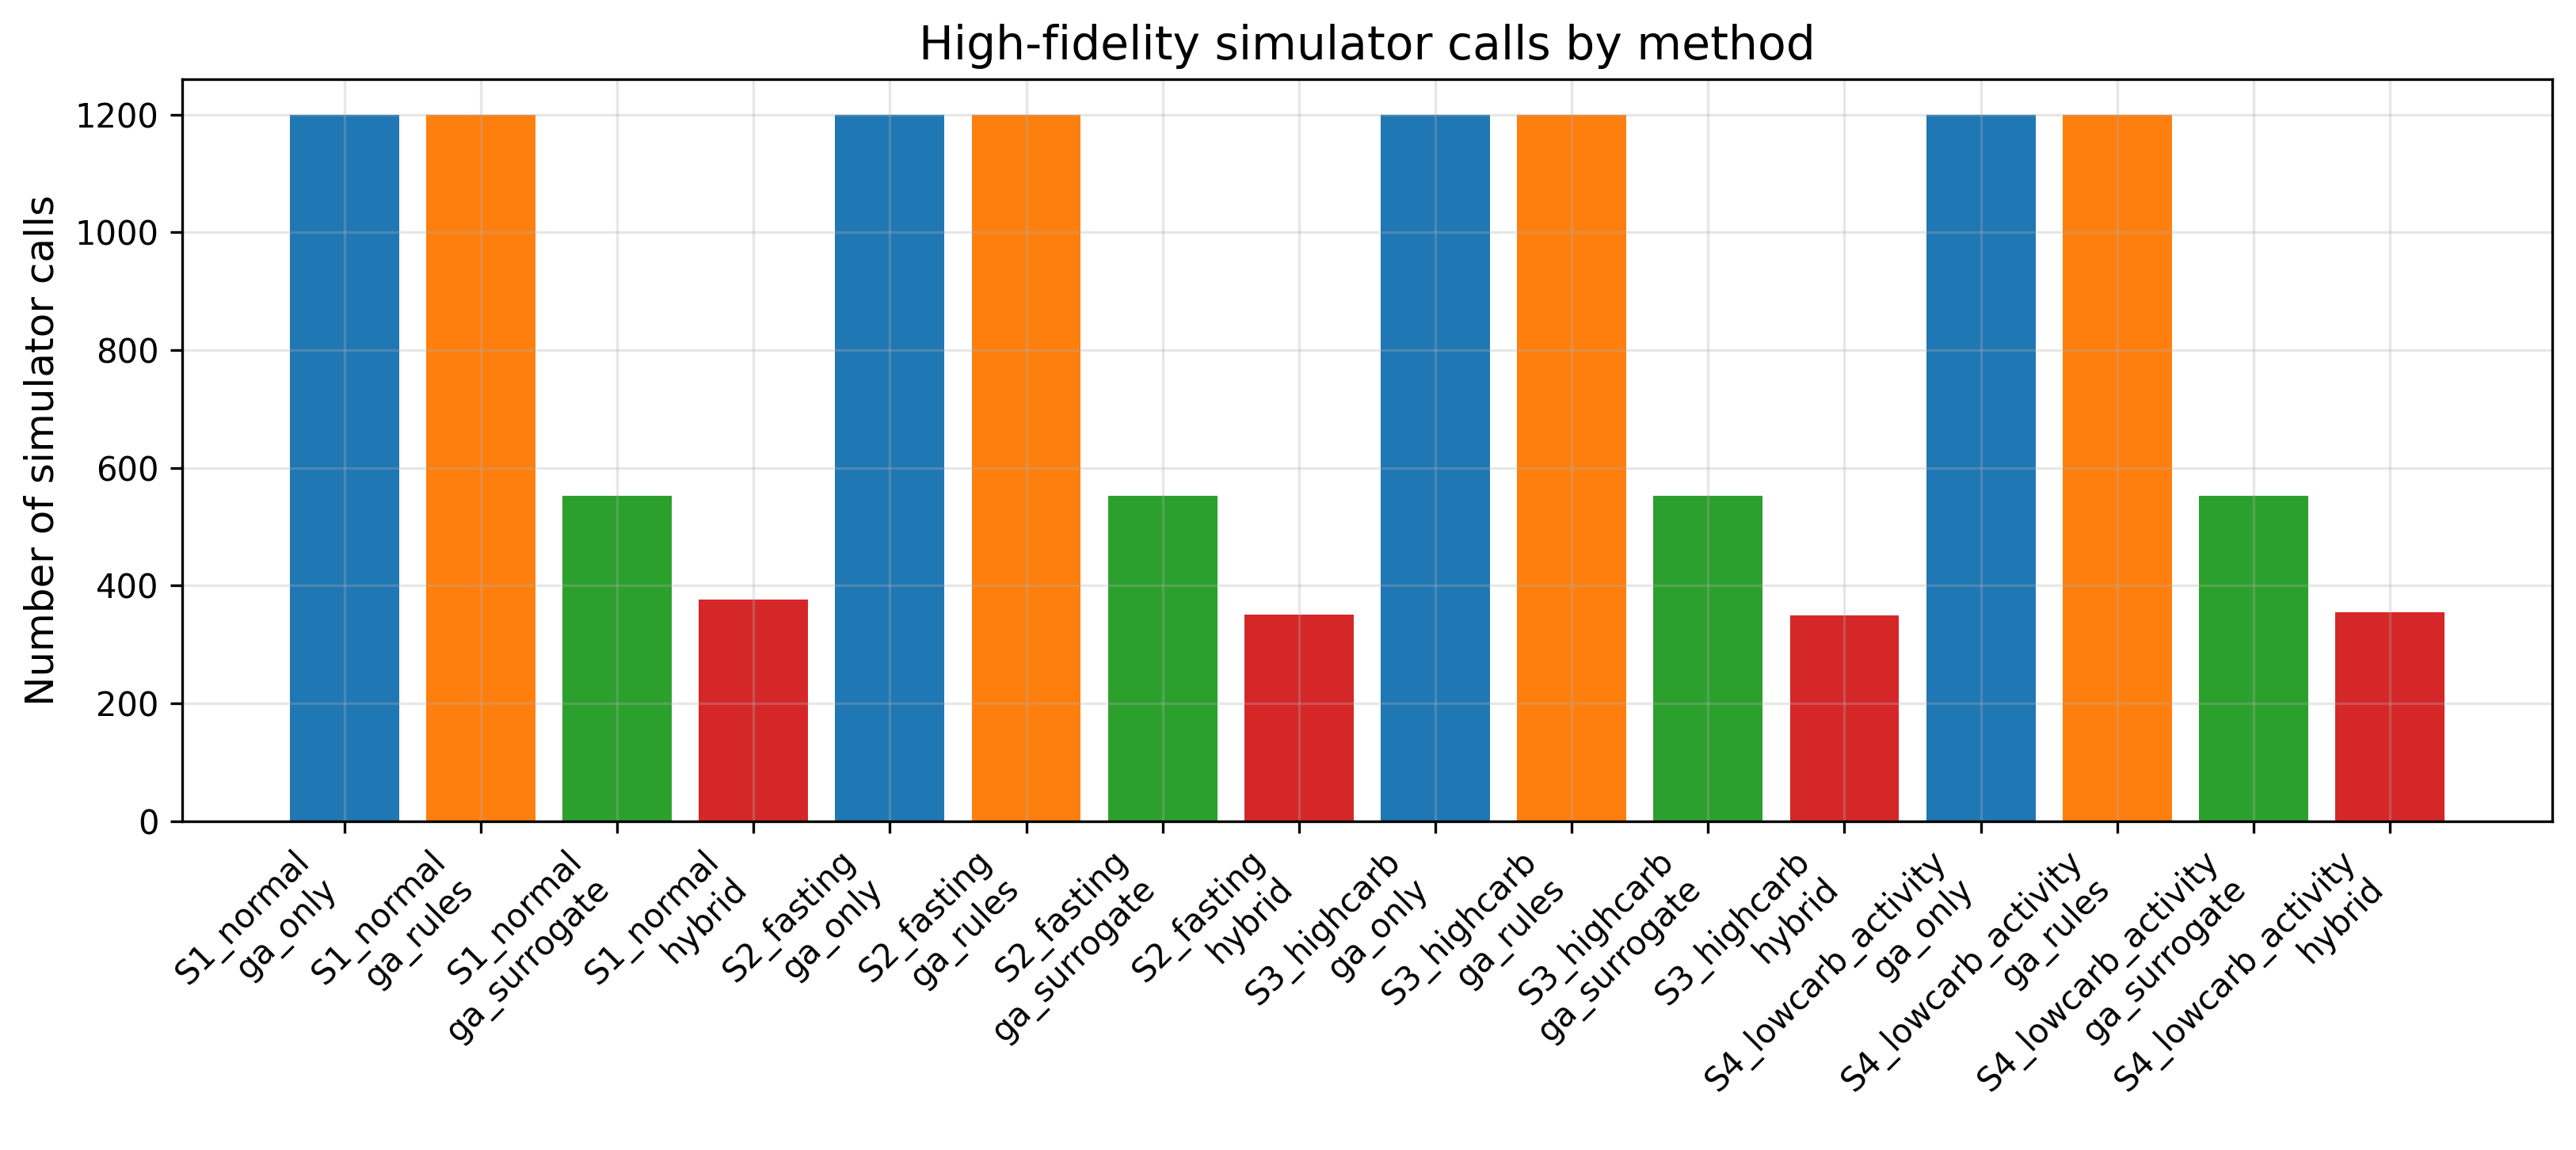

In [ ]:
#new2. Figure 1 — Simulator calls (version propre)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/results/summary_all_with_reduction.csv")

plt.figure(figsize=(11,5), dpi=300)

labels = []
values = []
colors = []

color_map = {
    "ga_only": "#1f77b4",
    "ga_rules": "#ff7f0e",
    "ga_surrogate": "#2ca02c",
    "hybrid": "#d62728",
}

for _, row in df.iterrows():
    labels.append(f"{row['Scenario']}\n{row['Method']}")
    values.append(row["SimCalls"])
    colors.append(color_map[row["Method"]])

bars = plt.bar(labels, values, color=colors)

plt.ylabel("Number of simulator calls")
plt.title("High-fidelity simulator calls by method")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "figures/sim_calls_comparison_clean.pdf",
    bbox_inches="tight"
)

plt.show()

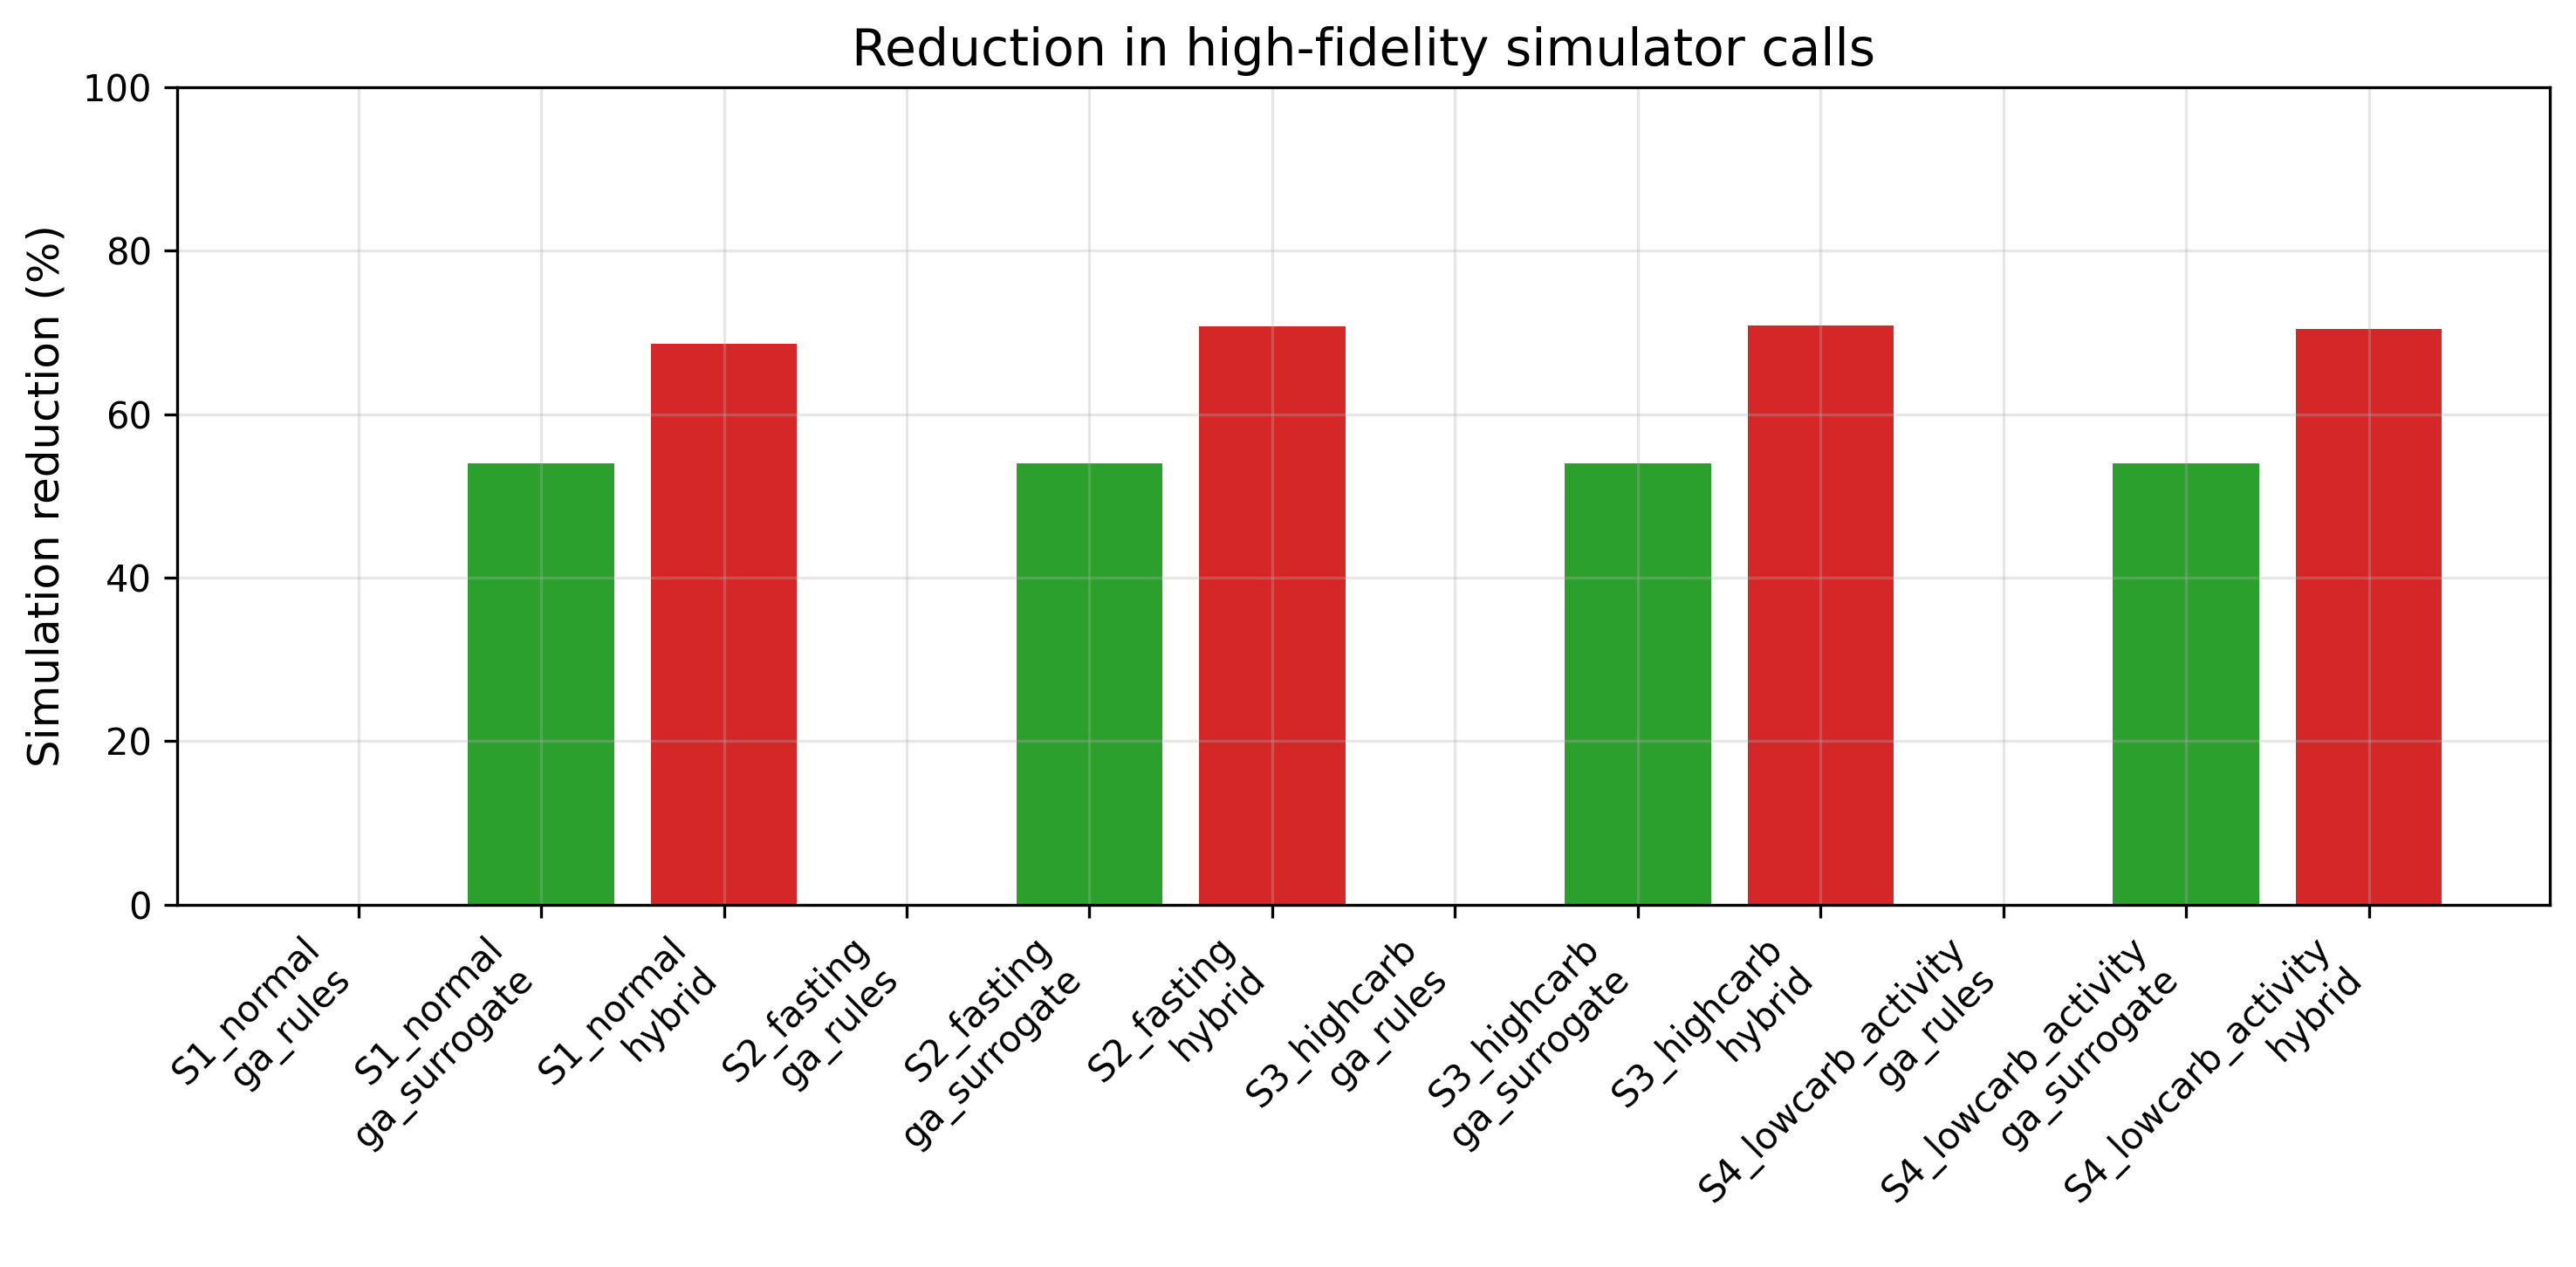

In [ ]:
#new 3. Figure 2 — Reduction %
sub = df[df["Method"] != "ga_only"]

plt.figure(figsize=(10,5), dpi=300)

labels = []
values = []
colors = []

for _, row in sub.iterrows():
    labels.append(f"{row['Scenario']}\n{row['Method']}")
    values.append(row["ReductionPct"])
    colors.append(color_map[row["Method"]])

plt.bar(labels, values, color=colors)

plt.ylabel("Simulation reduction (%)")
plt.title("Reduction in high-fidelity simulator calls")

plt.ylim(0, 100)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "figures/simulation_reduction_percent_clean.pdf",
    bbox_inches="tight"
)

plt.show()

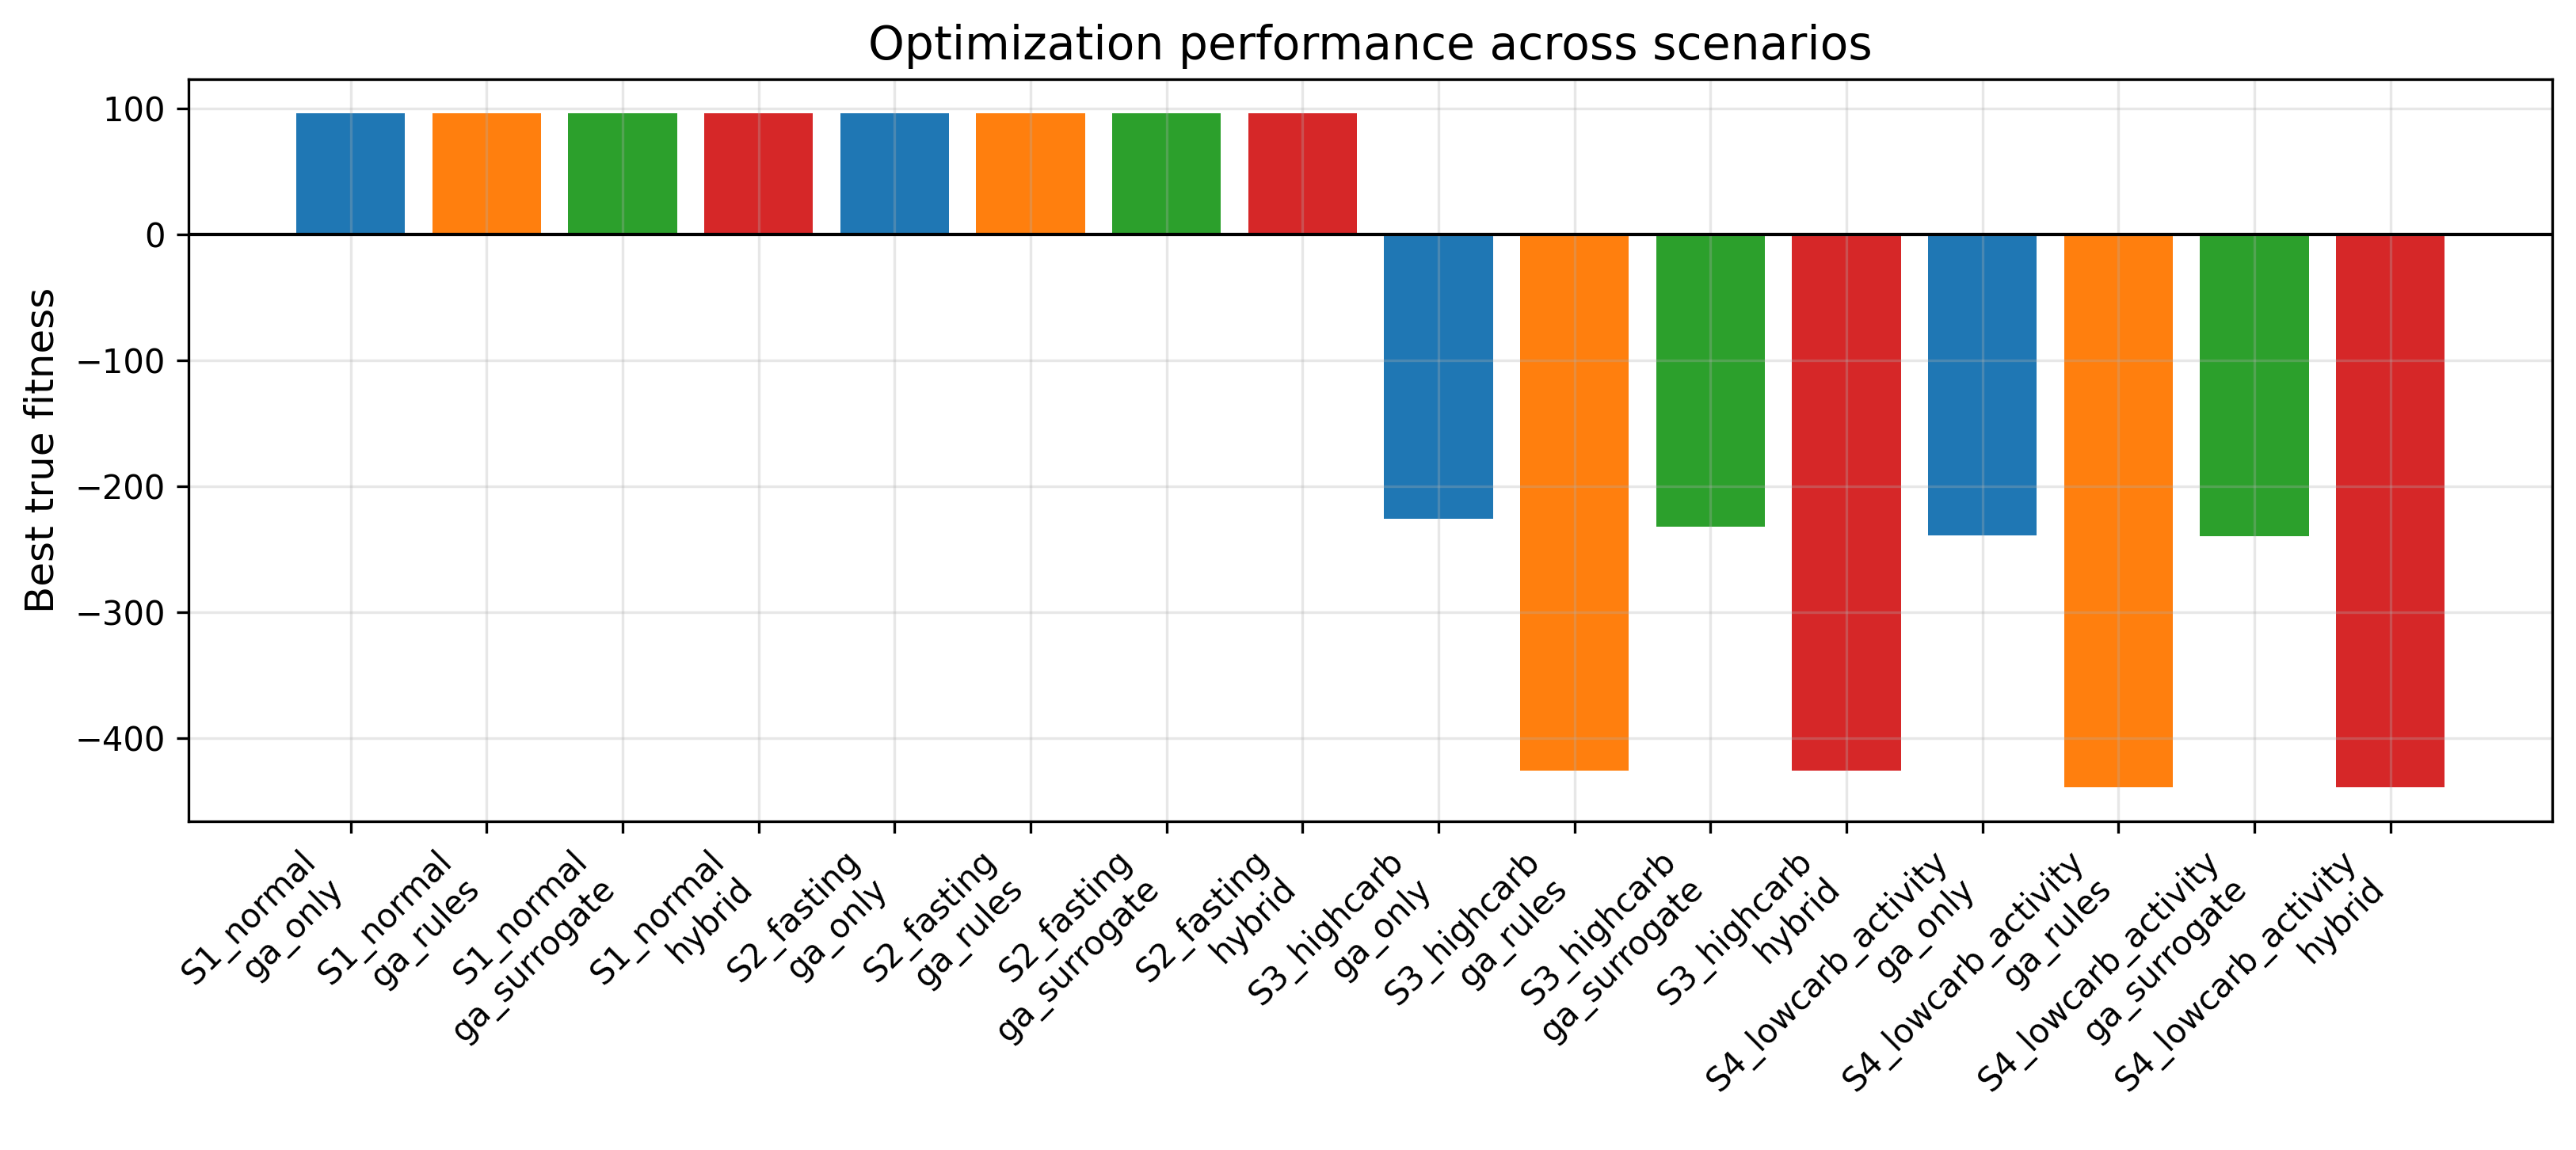

In [ ]:
#new 4. Figure 3 — Fitness comparison (TRÈS IMPORTANT)
plt.figure(figsize=(11,5), dpi=300)

labels = []
values = []
colors = []

for _, row in df.iterrows():
    labels.append(f"{row['Scenario']}\n{row['Method']}")
    values.append(row["Fitness"])
    colors.append(color_map[row["Method"]])

plt.bar(labels, values, color=colors)

plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Best true fitness")
plt.title("Optimization performance across scenarios")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "figures/fitness_comparison_clean.pdf",
    bbox_inches="tight"
)

plt.show()

In [ ]:
#relance seulement S1 pour générer les fichiers history
!python src/run_experiments.py --scenario S1_normal --methods ALL --save_figs

[INFO] Using 3D simglucose chromosome: [basal_rate, carb_ratio, correction_factor]

=== Running scenario: S1_normal ===
ga_only      | best=  96.33 | fit_out=  96.33 | AUCsum=  2889.5 | AUCmean=  96.32 | AUCregret=     0.4 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  97.3 | maxG= 176.2 | dataset=1200 | sim_calls=1200 | backend=simglucose
ga_rules     | best=  96.33 | fit_out=  96.33 | AUCsum=  2888.4 | AUCmean=  96.28 | AUCregret=     1.5 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  97.3 | maxG= 176.2 | dataset=1200 | sim_calls=1200 | backend=simglucose
ga_surrogate | best=  96.33 | fit_out=  96.33 | AUCsum=  2889.3 | AUCmean=  96.31 | AUCregret=     0.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  97.3 | maxG= 176.2 | dataset=552 | sim_calls=552 | backend=simglucose
hybrid       | best=  96.33 | fit_out=  96.33 | AUCsum=  2888.3 | AUCmean=  96.28 | AUCregret=     1.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  97.3 | maxG= 176.2 | dataset=376 | sim_calls=376 | backend=simglucose

[DEBUG]

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "outputs/results"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(f"{RESULTS_DIR}/summary_all_with_reduction.csv")

scenario = "S1_normal"

pretty = {
    "ga_only": "GA",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "Surrogate-GA",
    "hybrid": "Hybrid"
}

colors = {
    "ga_only": "tab:blue",
    "ga_rules": "tab:orange",
    "ga_surrogate": "tab:green",
    "hybrid": "tab:red"
}

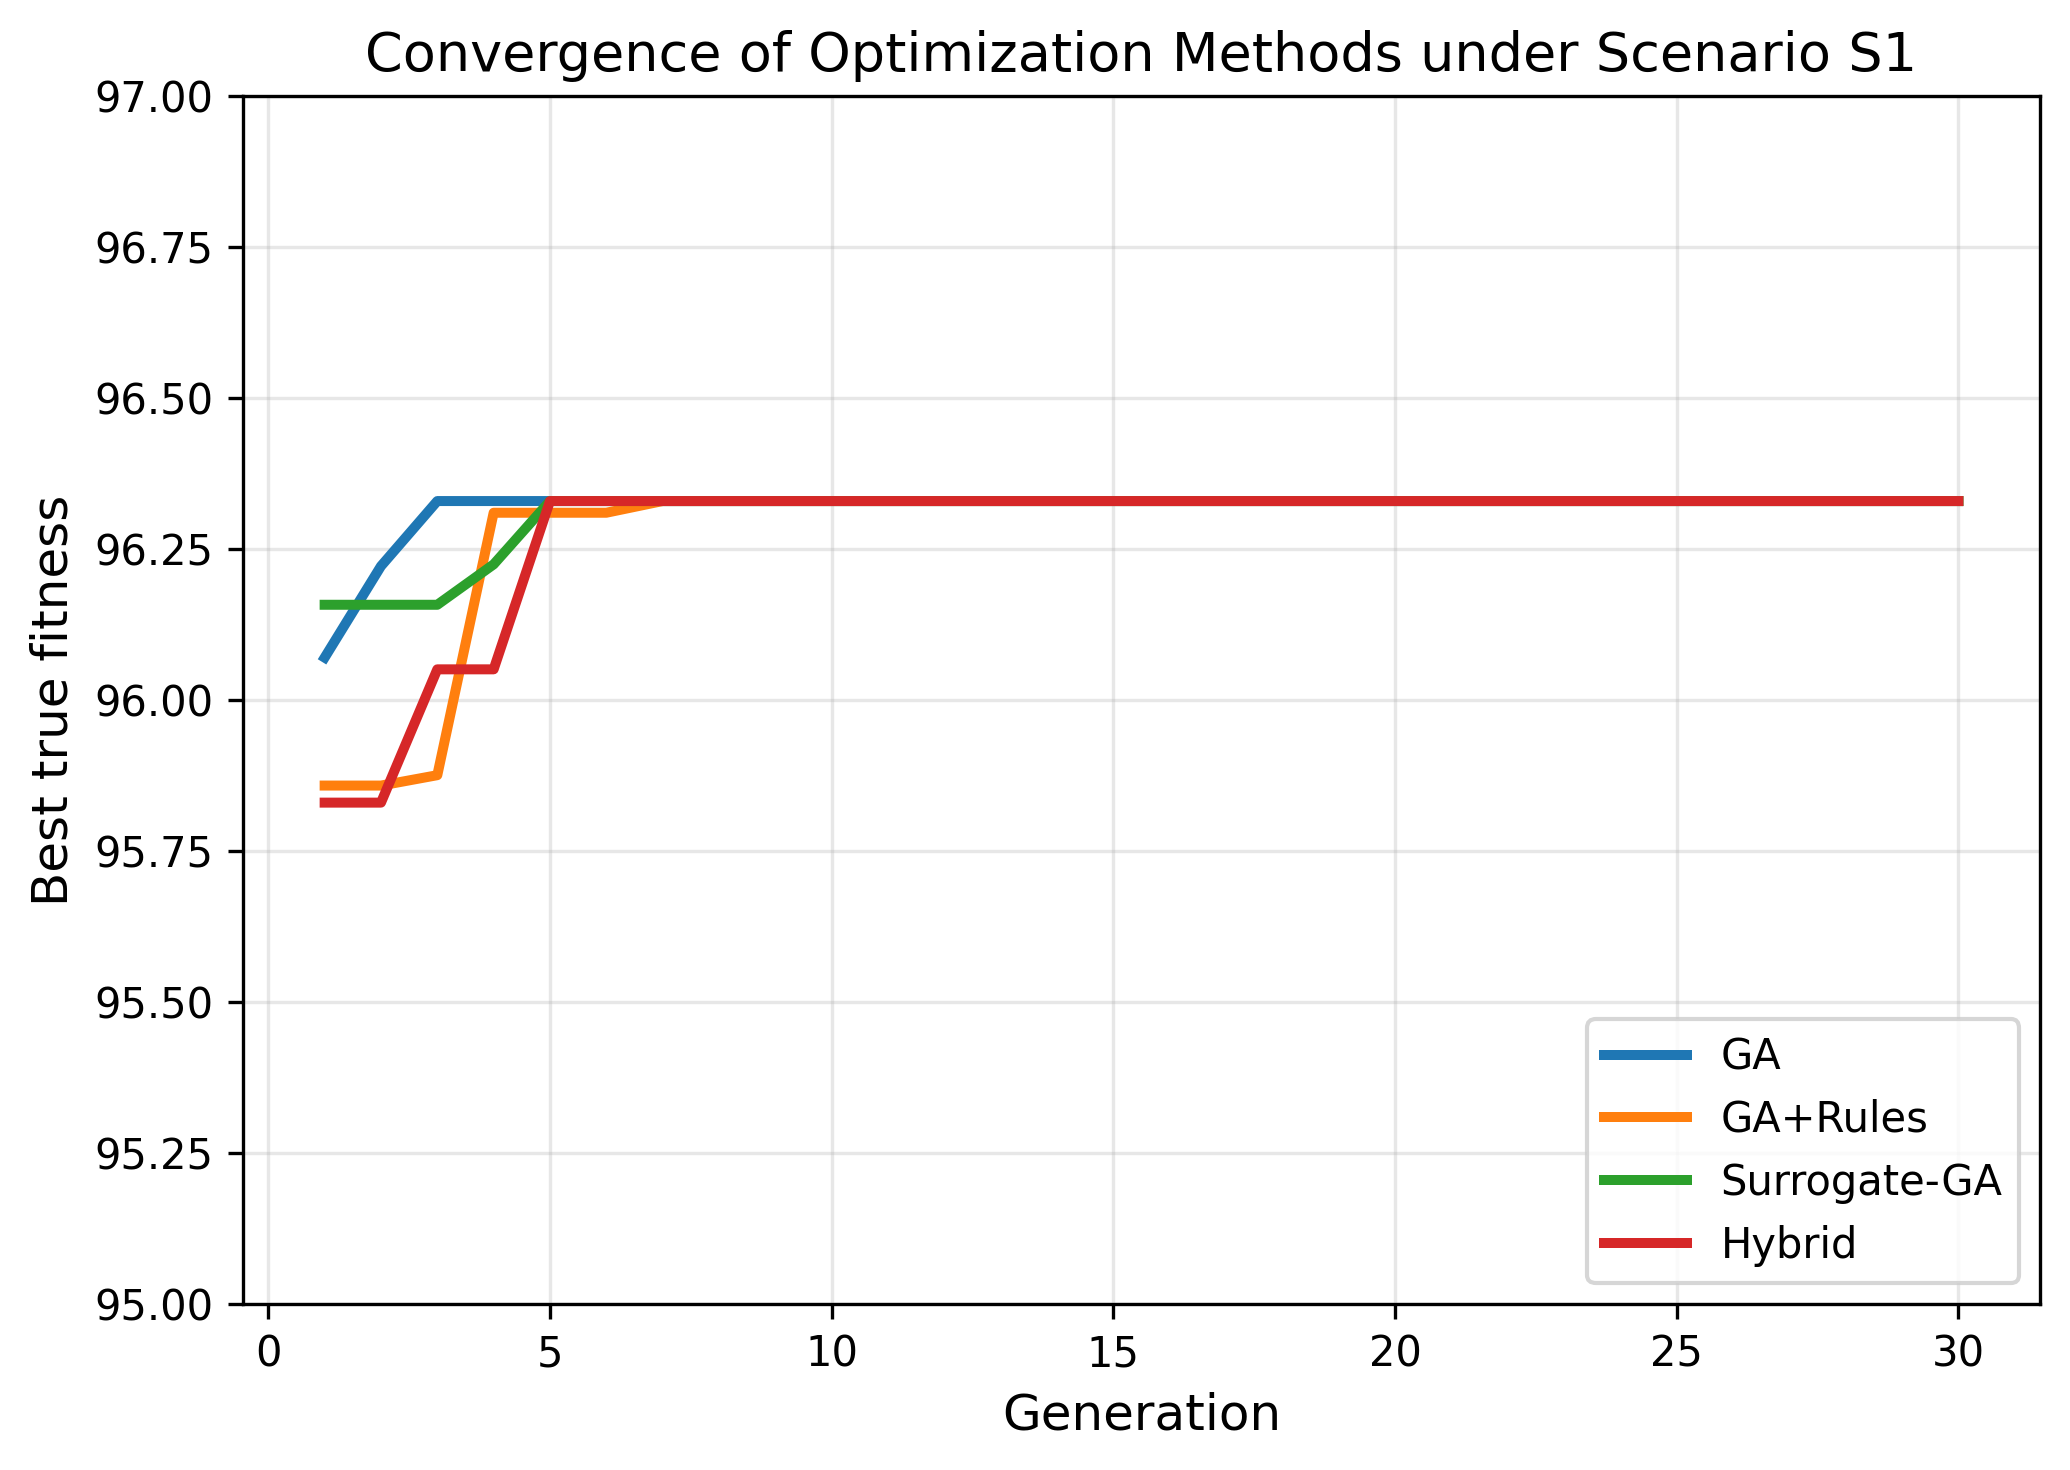

In [ ]:
# 1. new newwwwFigure convergence correcteplt.figure(figsize=(7, 5), dpi=300)
import os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "outputs/results"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

scenario = "S1_normal"

pretty = {
    "ga_only": "GA",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "Surrogate-GA",
    "hybrid": "Hybrid"
}

colors = {
    "ga_only": "tab:blue",
    "ga_rules": "tab:orange",
    "ga_surrogate": "tab:green",
    "hybrid": "tab:red"
}

plt.figure(figsize=(7, 5), dpi=300)

for method in ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]:

    path = os.path.join(RESULTS_DIR, f"history_{scenario}_{method}.npy")

    if not os.path.exists(path):
        print(f"[MISSING] {path}")
        continue

    h = np.load(path).astype(float).flatten()

    if h.size == 0:
        print(f"[EMPTY] {path}")
        continue

    plt.plot(
        np.arange(1, len(h) + 1),
        h,
        linewidth=2.4,
        color=colors[method],
        label=pretty[method]
    )

plt.xlabel("Generation", fontsize=12)
plt.ylabel("Best true fitness", fontsize=12)
plt.title("Convergence of Optimization Methods under Scenario S1", fontsize=13)

plt.ylim(95.0, 97.0)
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=10, loc="lower right")
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "fig1_convergence_s1.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(FIG_DIR, "fig1_convergence_s1.png"), dpi=300, bbox_inches="tight")
plt.show()



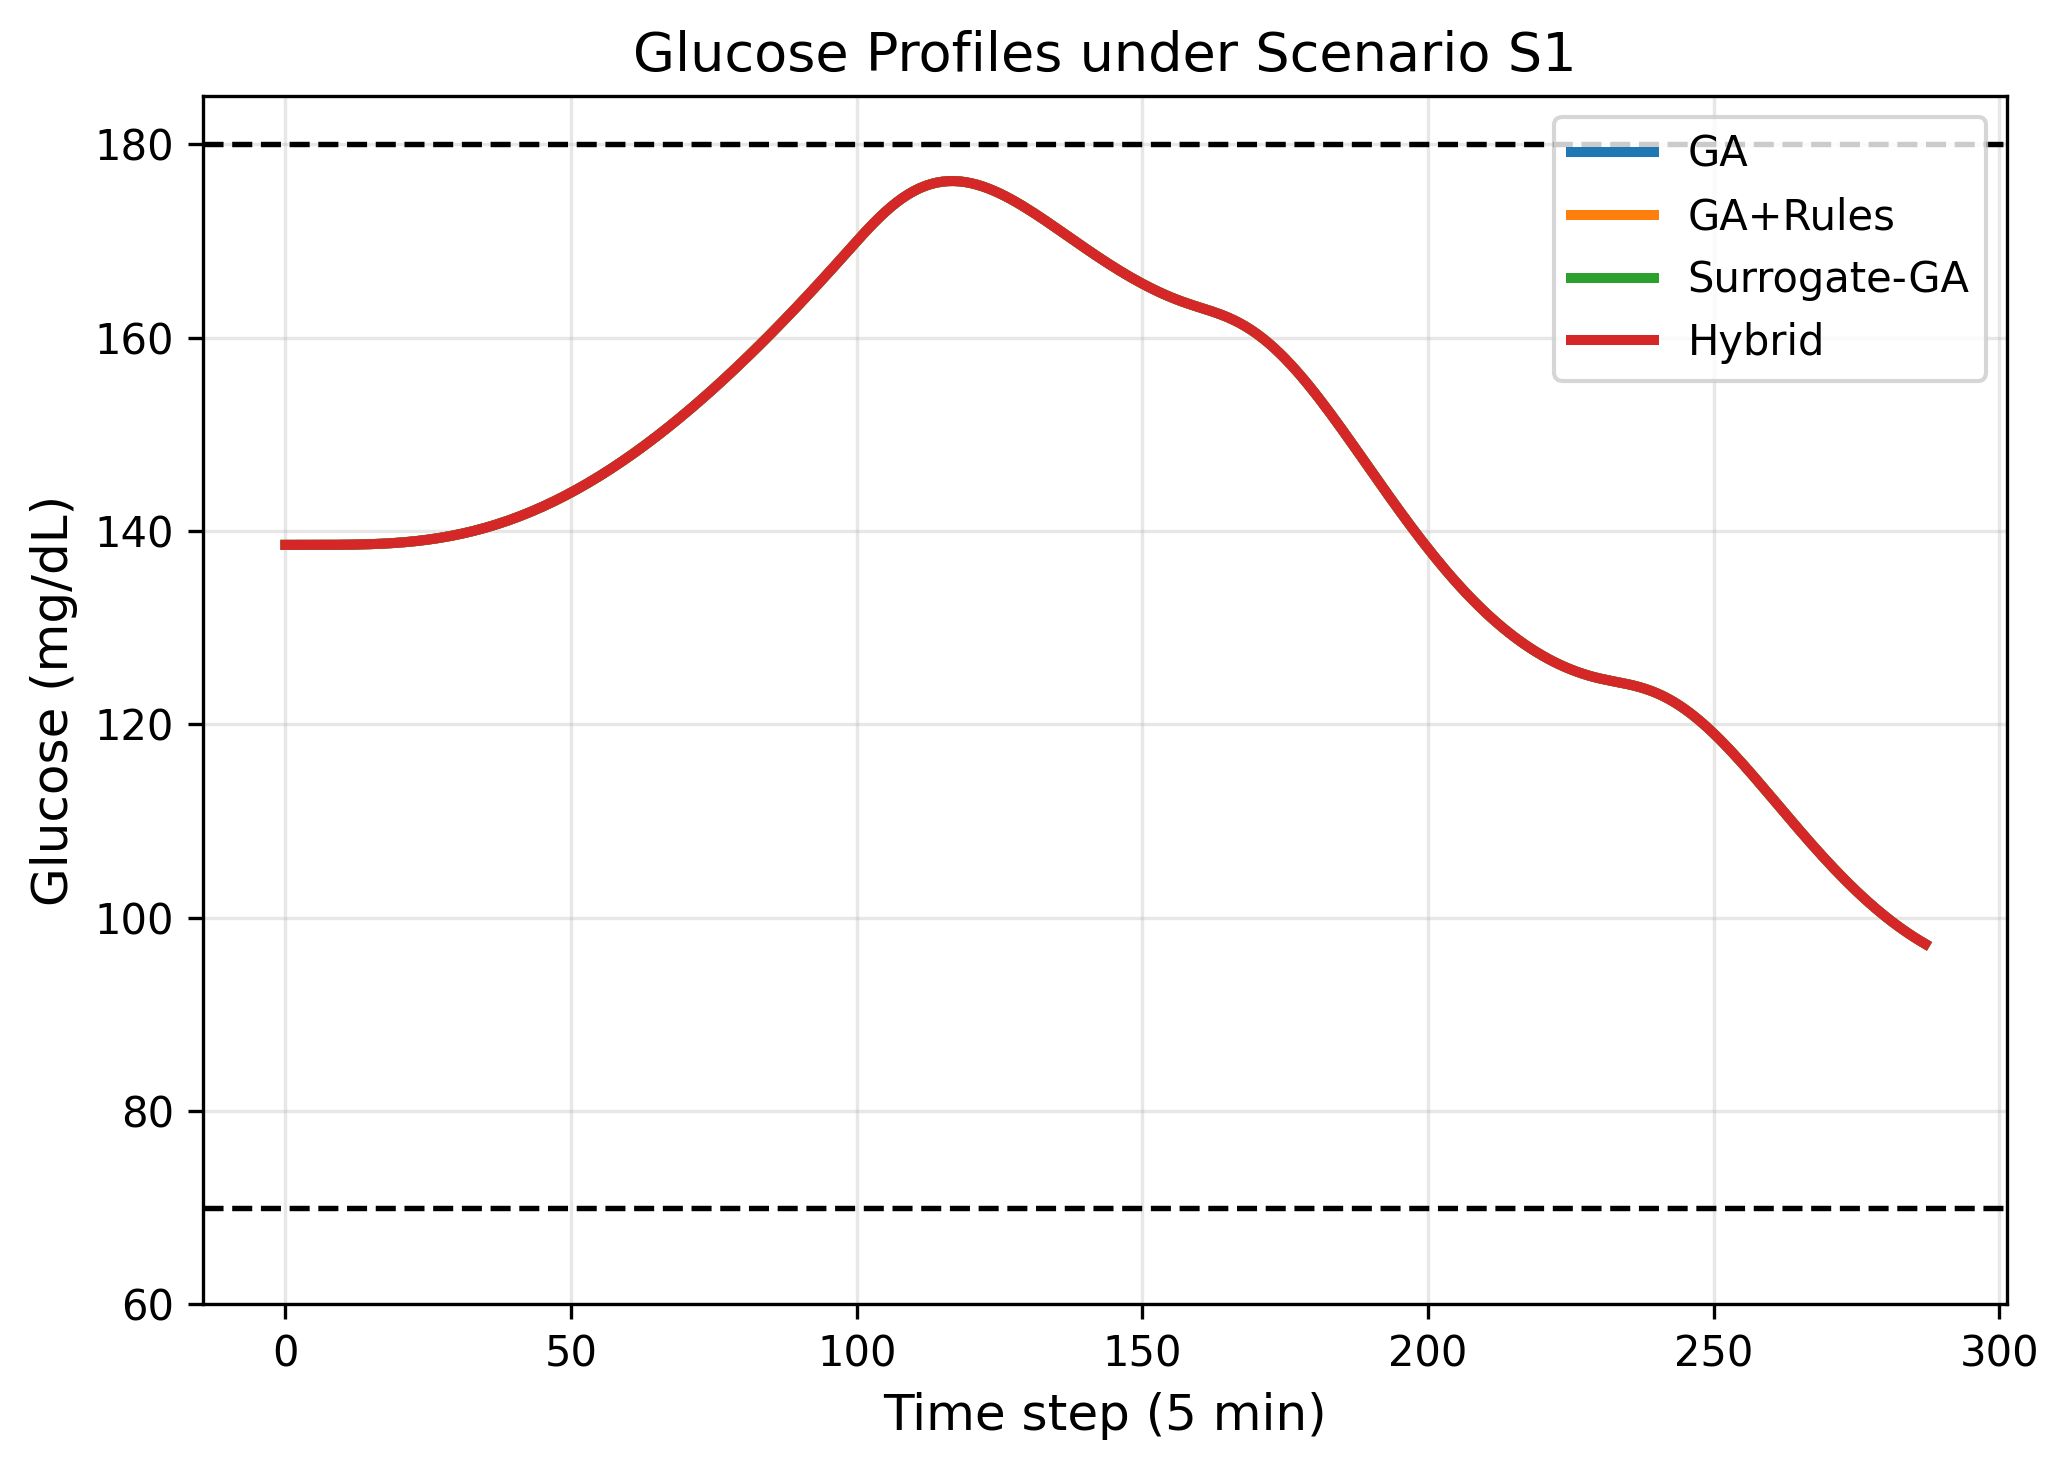

In [ ]:
# newwwwwwwwwwww2. Figure glucose correcteimport os
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = "outputs/results"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

scenario = "S1_normal"

pretty = {
    "ga_only": "GA",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "Surrogate-GA",
    "hybrid": "Hybrid"
}

colors = {
    "ga_only": "tab:blue",
    "ga_rules": "tab:orange",
    "ga_surrogate": "tab:green",
    "hybrid": "tab:red"
}

plt.figure(figsize=(7, 5), dpi=300)

for method in ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]:

    path = os.path.join(RESULTS_DIR, f"glucose_{scenario}_{method}.npy")

    if not os.path.exists(path):
        path = os.path.join(RESULTS_DIR, f"G_{scenario}_{method}.npy")

    if not os.path.exists(path):
        print(f"[MISSING] glucose file for {method}")
        continue

    G = np.load(path).astype(float).flatten()

    if G.size == 0:
        print(f"[EMPTY] {path}")
        continue

    plt.plot(
        np.arange(len(G)),
        G,
        linewidth=2.4,
        color=colors[method],
        label=pretty[method]
    )

plt.axhline(70, linestyle="--", color="black", linewidth=1.3)
plt.axhline(180, linestyle="--", color="black", linewidth=1.3)

plt.xlabel("Time step (5 min)", fontsize=12)
plt.ylabel("Glucose (mg/dL)", fontsize=12)
plt.title("Glucose Profiles under Scenario S1", fontsize=13)

plt.ylim(60, 185)
plt.grid(alpha=0.3)
plt.legend(frameon=True, fontsize=10, loc="upper right")
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "fig2_glucose_s1.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(FIG_DIR, "fig2_glucose_s1.png"), dpi=300, bbox_inches="tight")
plt.show()

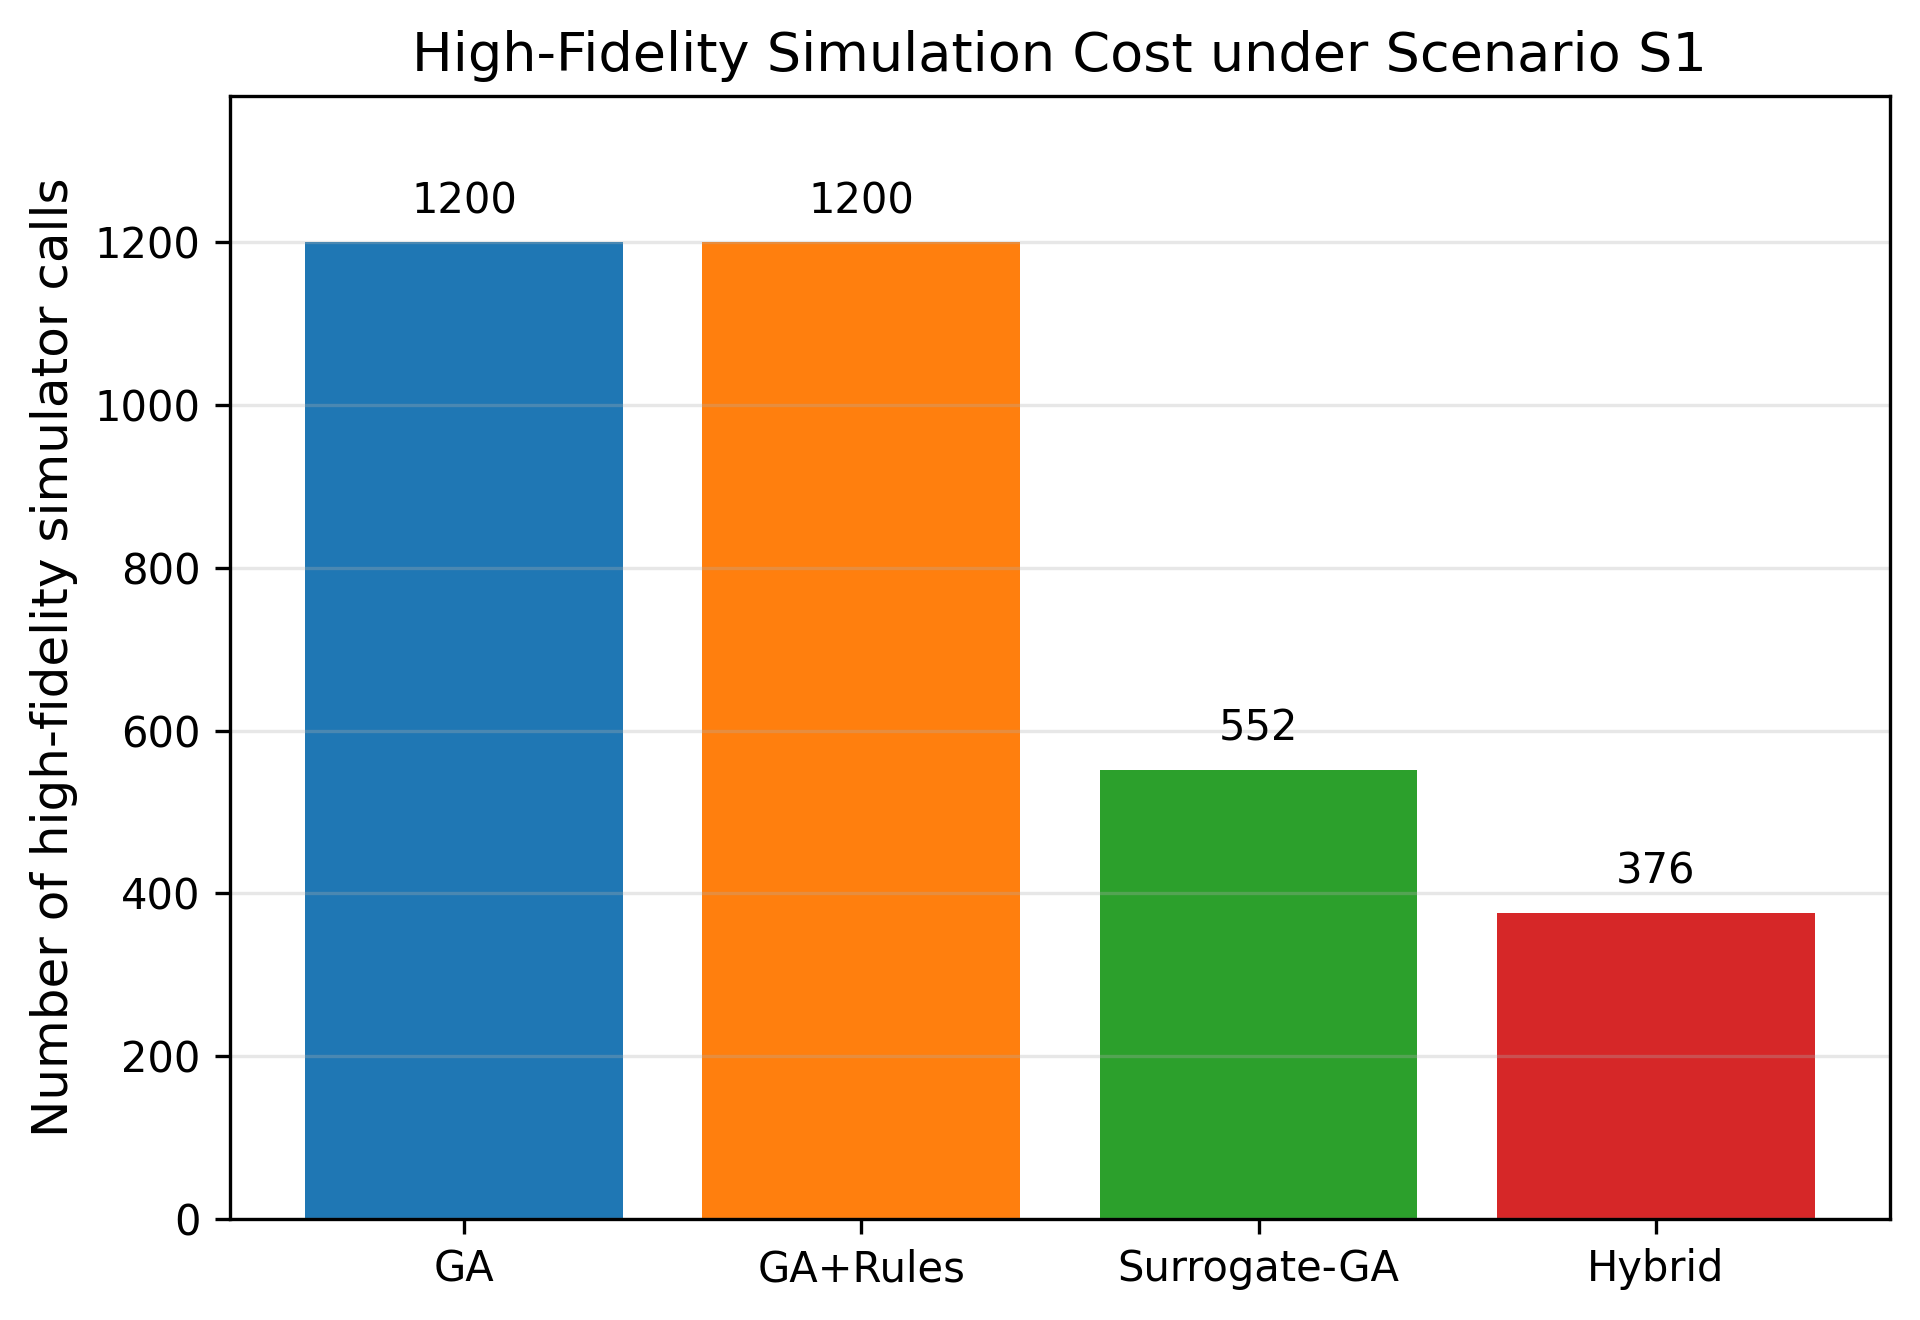

In [ ]:
# 3. newwwwwwwwwwwwFigure coût simulation propre
import os
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "outputs/results"
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

scenario = "S1_normal"

df = pd.read_csv(os.path.join(RESULTS_DIR, "summary_all_with_reduction.csv"))
sub = df[df["Scenario"] == scenario].copy()

method_order = ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]
sub["Method"] = pd.Categorical(sub["Method"], categories=method_order, ordered=True)
sub = sub.sort_values("Method")

pretty = {
    "ga_only": "GA",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "Surrogate-GA",
    "hybrid": "Hybrid"
}

colors = {
    "ga_only": "tab:blue",
    "ga_rules": "tab:orange",
    "ga_surrogate": "tab:green",
    "hybrid": "tab:red"
}

labels = [pretty[m] for m in sub["Method"]]
values = sub["SimCalls"].astype(int).values
bar_colors = [colors[m] for m in sub["Method"]]

plt.figure(figsize=(6.5, 4.5), dpi=300)

bars = plt.bar(labels, values, color=bar_colors)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 25,
        str(value),
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("Number of high-fidelity simulator calls", fontsize=12)
plt.title("High-Fidelity Simulation Cost under Scenario S1", fontsize=13)

plt.ylim(0, max(values) * 1.15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(os.path.join(FIG_DIR, "fig3_simulation_cost_s1.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(FIG_DIR, "fig3_simulation_cost_s1.png"), dpi=300, bbox_inches="tight")
plt.show()

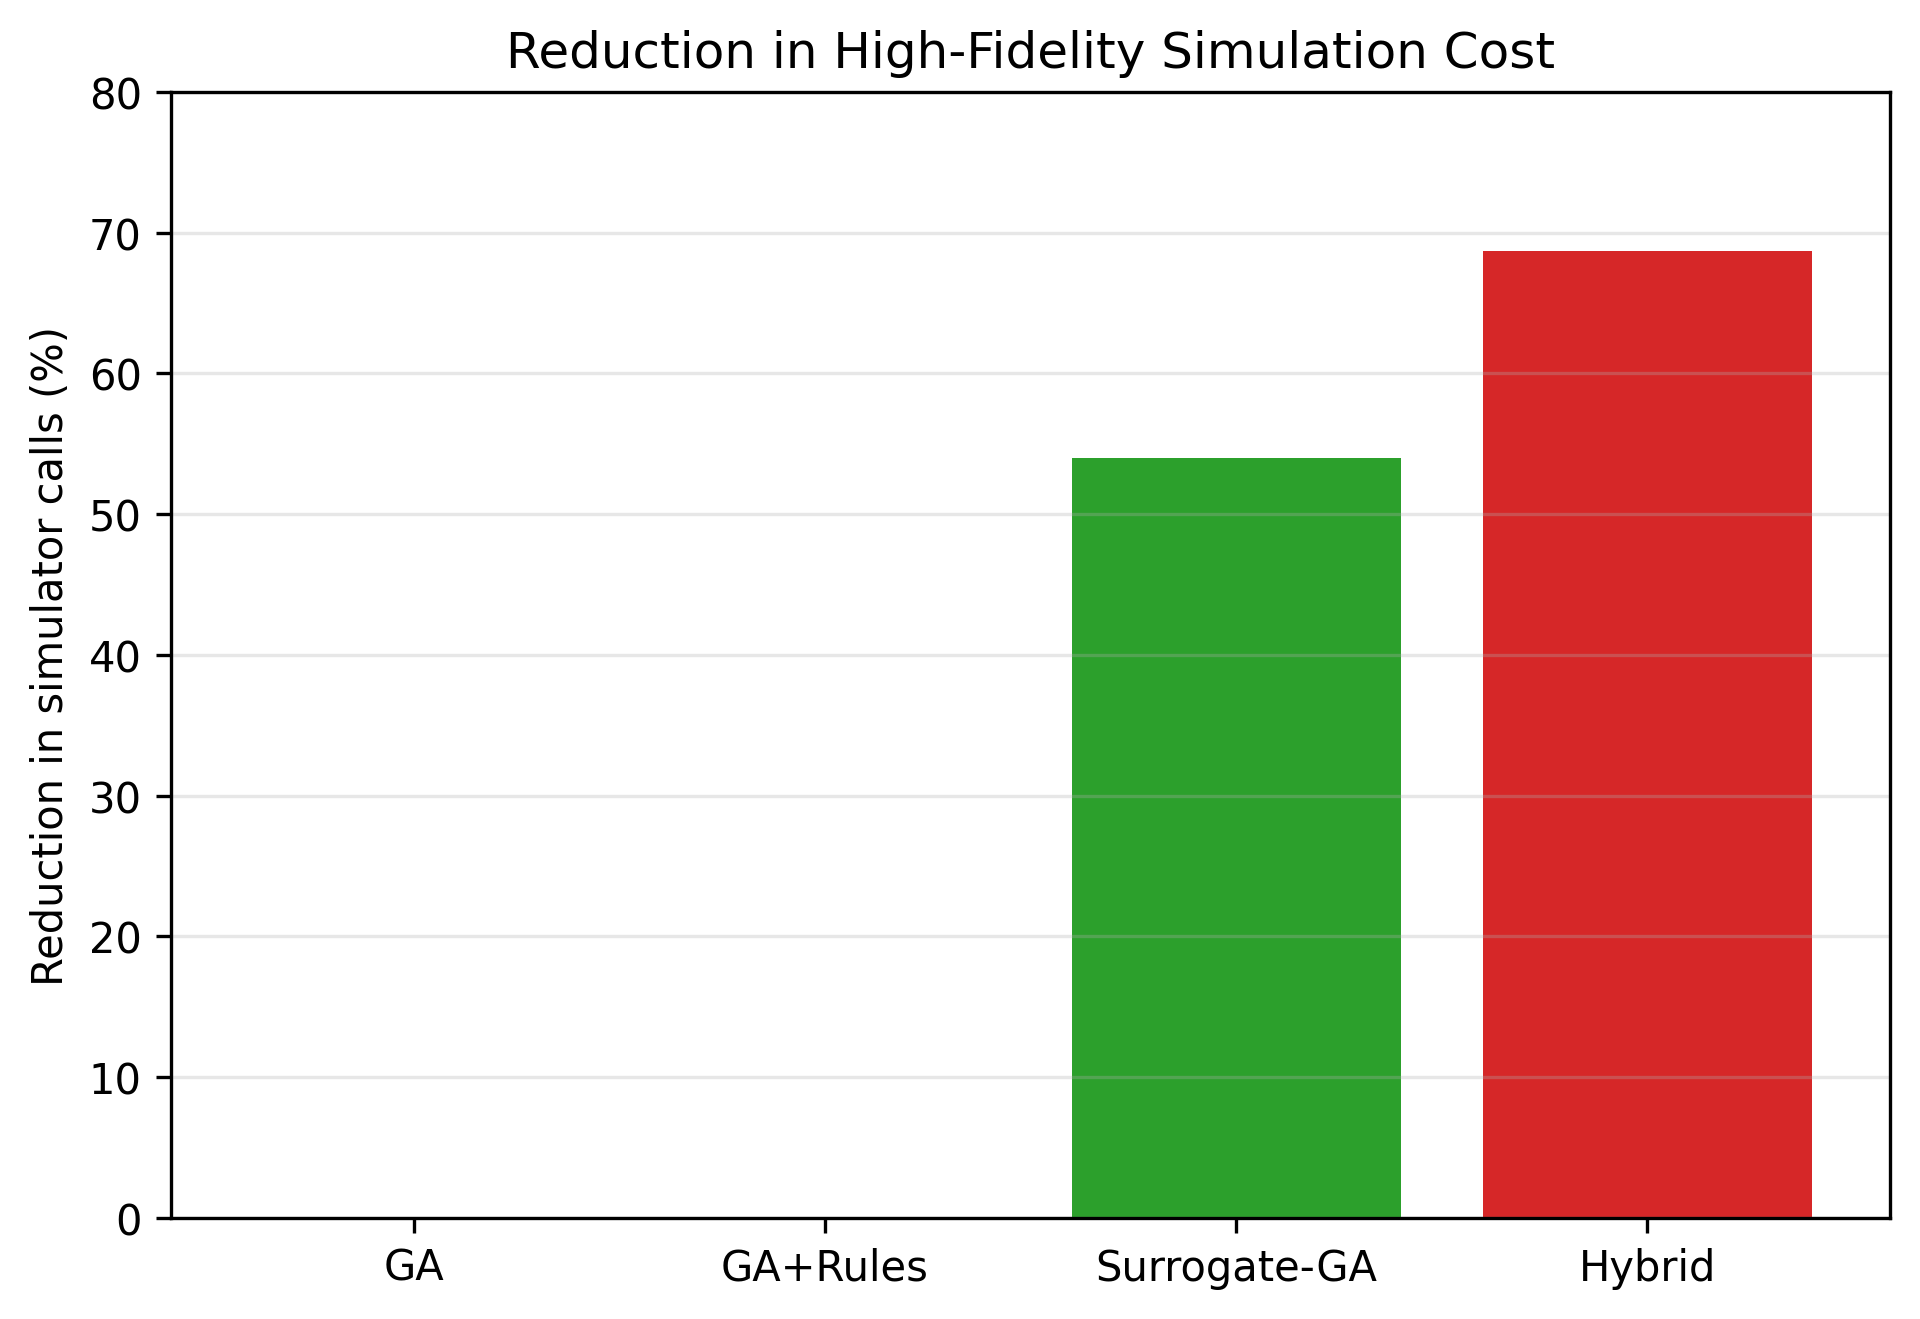

In [ ]:
# newwwwwwwwwwwww 4. Figure réduction propre
plt.figure(figsize=(6.5, 4.5), dpi=300)

plt.bar(
    [pretty[m] for m in sub["Method"]],
    sub["ReductionPct"],
    color=[colors[m] for m in sub["Method"]]
)

plt.ylabel("Reduction in simulator calls (%)")
plt.title("Reduction in High-Fidelity Simulation Cost")
plt.ylim(0, 80)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/fig_reduction_s1.pdf", bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/fig_reduction_s1.png", dpi=300, bbox_inches="tight")
plt.show()

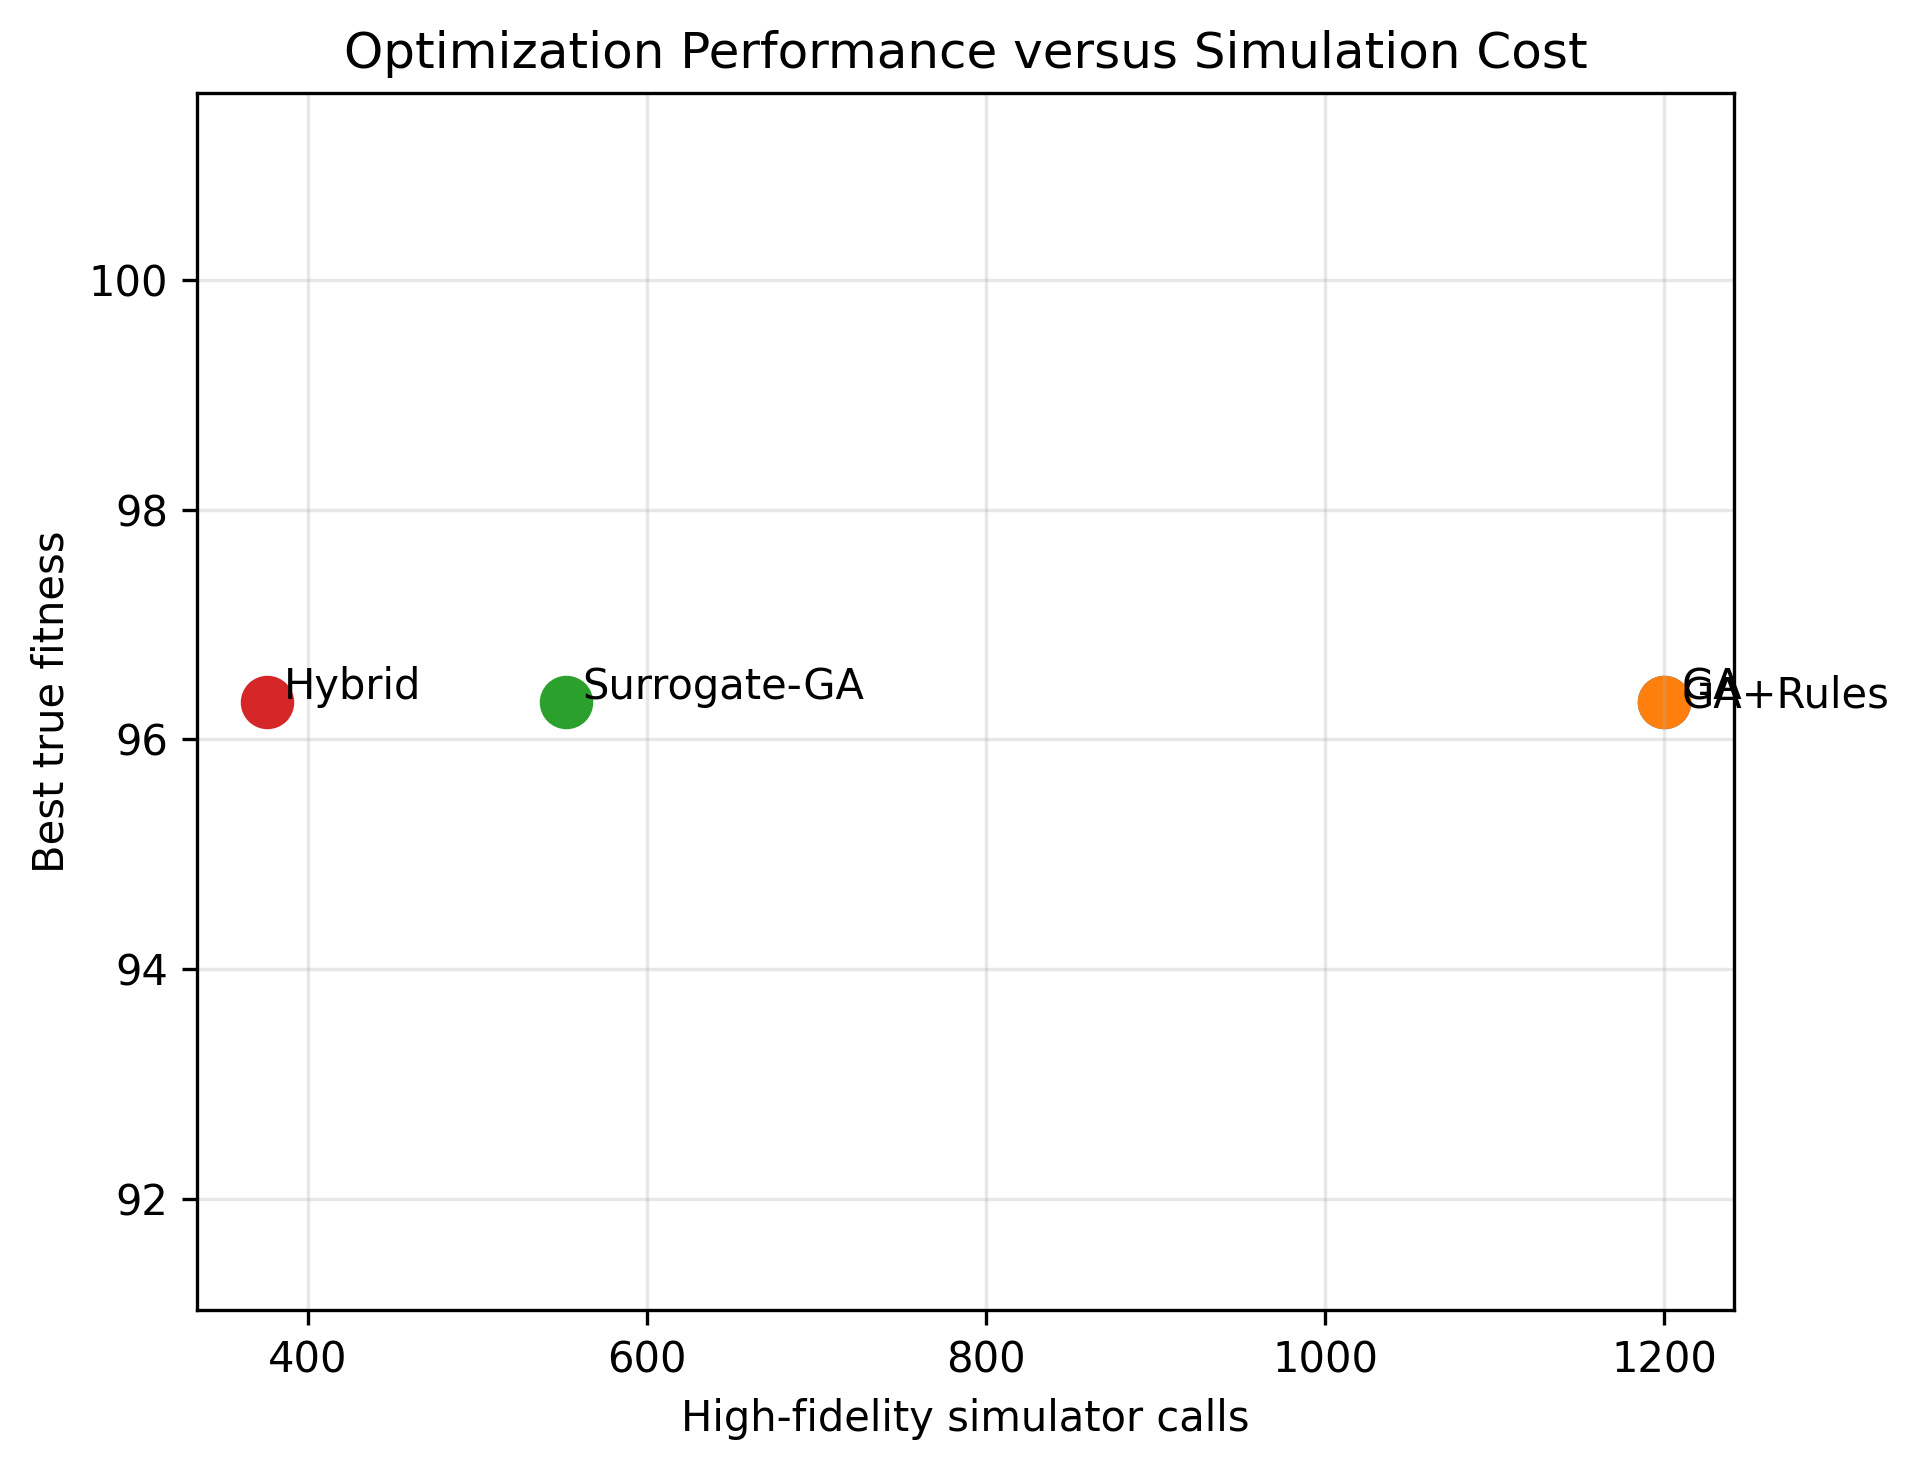

In [ ]:
# newwwwwwwww 5. Figure fitness vs coût corrigée
plt.figure(figsize=(6.5, 5), dpi=300)

offsets = {
    "ga_only": (10, 0.02),
    "ga_rules": (10, -0.05),
    "ga_surrogate": (10, 0.02),
    "hybrid": (10, 0.02)
}

for _, row in sub.iterrows():
    method = row["Method"]

    plt.scatter(
        row["SimCalls"],
        row["Fitness"],
        s=140,
        color=colors[method],
        label=pretty[method]
    )

    dx, dy = offsets[method]

    plt.text(
        row["SimCalls"] + dx,
        row["Fitness"] + dy,
        pretty[method],
        fontsize=10
    )

plt.xlabel("High-fidelity simulator calls")
plt.ylabel("Best true fitness")
plt.title("Optimization Performance versus Simulation Cost")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(f"{FIG_DIR}/fig_fitness_cost_s1.pdf", bbox_inches="tight")
plt.savefig(f"{FIG_DIR}/fig_fitness_cost_s1.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np

for method in ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]:

    G = np.load(f"outputs/results/G_S1_normal_{method}.npy")

    print(method)
    print(G[:10])
    print()

ga_only
[138.56000001 138.56000103 138.56001186 138.56006343 138.56022303
 138.56060393 138.56136993 138.56273549 138.56496283 138.56835702]

ga_rules
[138.56000001 138.56000103 138.56001186 138.56006343 138.56022303
 138.56060393 138.56136993 138.56273549 138.56496283 138.56835702]

ga_surrogate
[138.56000001 138.56000103 138.56001186 138.56006343 138.56022303
 138.56060393 138.56136993 138.56273549 138.56496283 138.56835702]

hybrid
[138.56000001 138.56000103 138.56001186 138.56006343 138.56022303
 138.56060393 138.56136993 138.56273549 138.56496283 138.56835702]



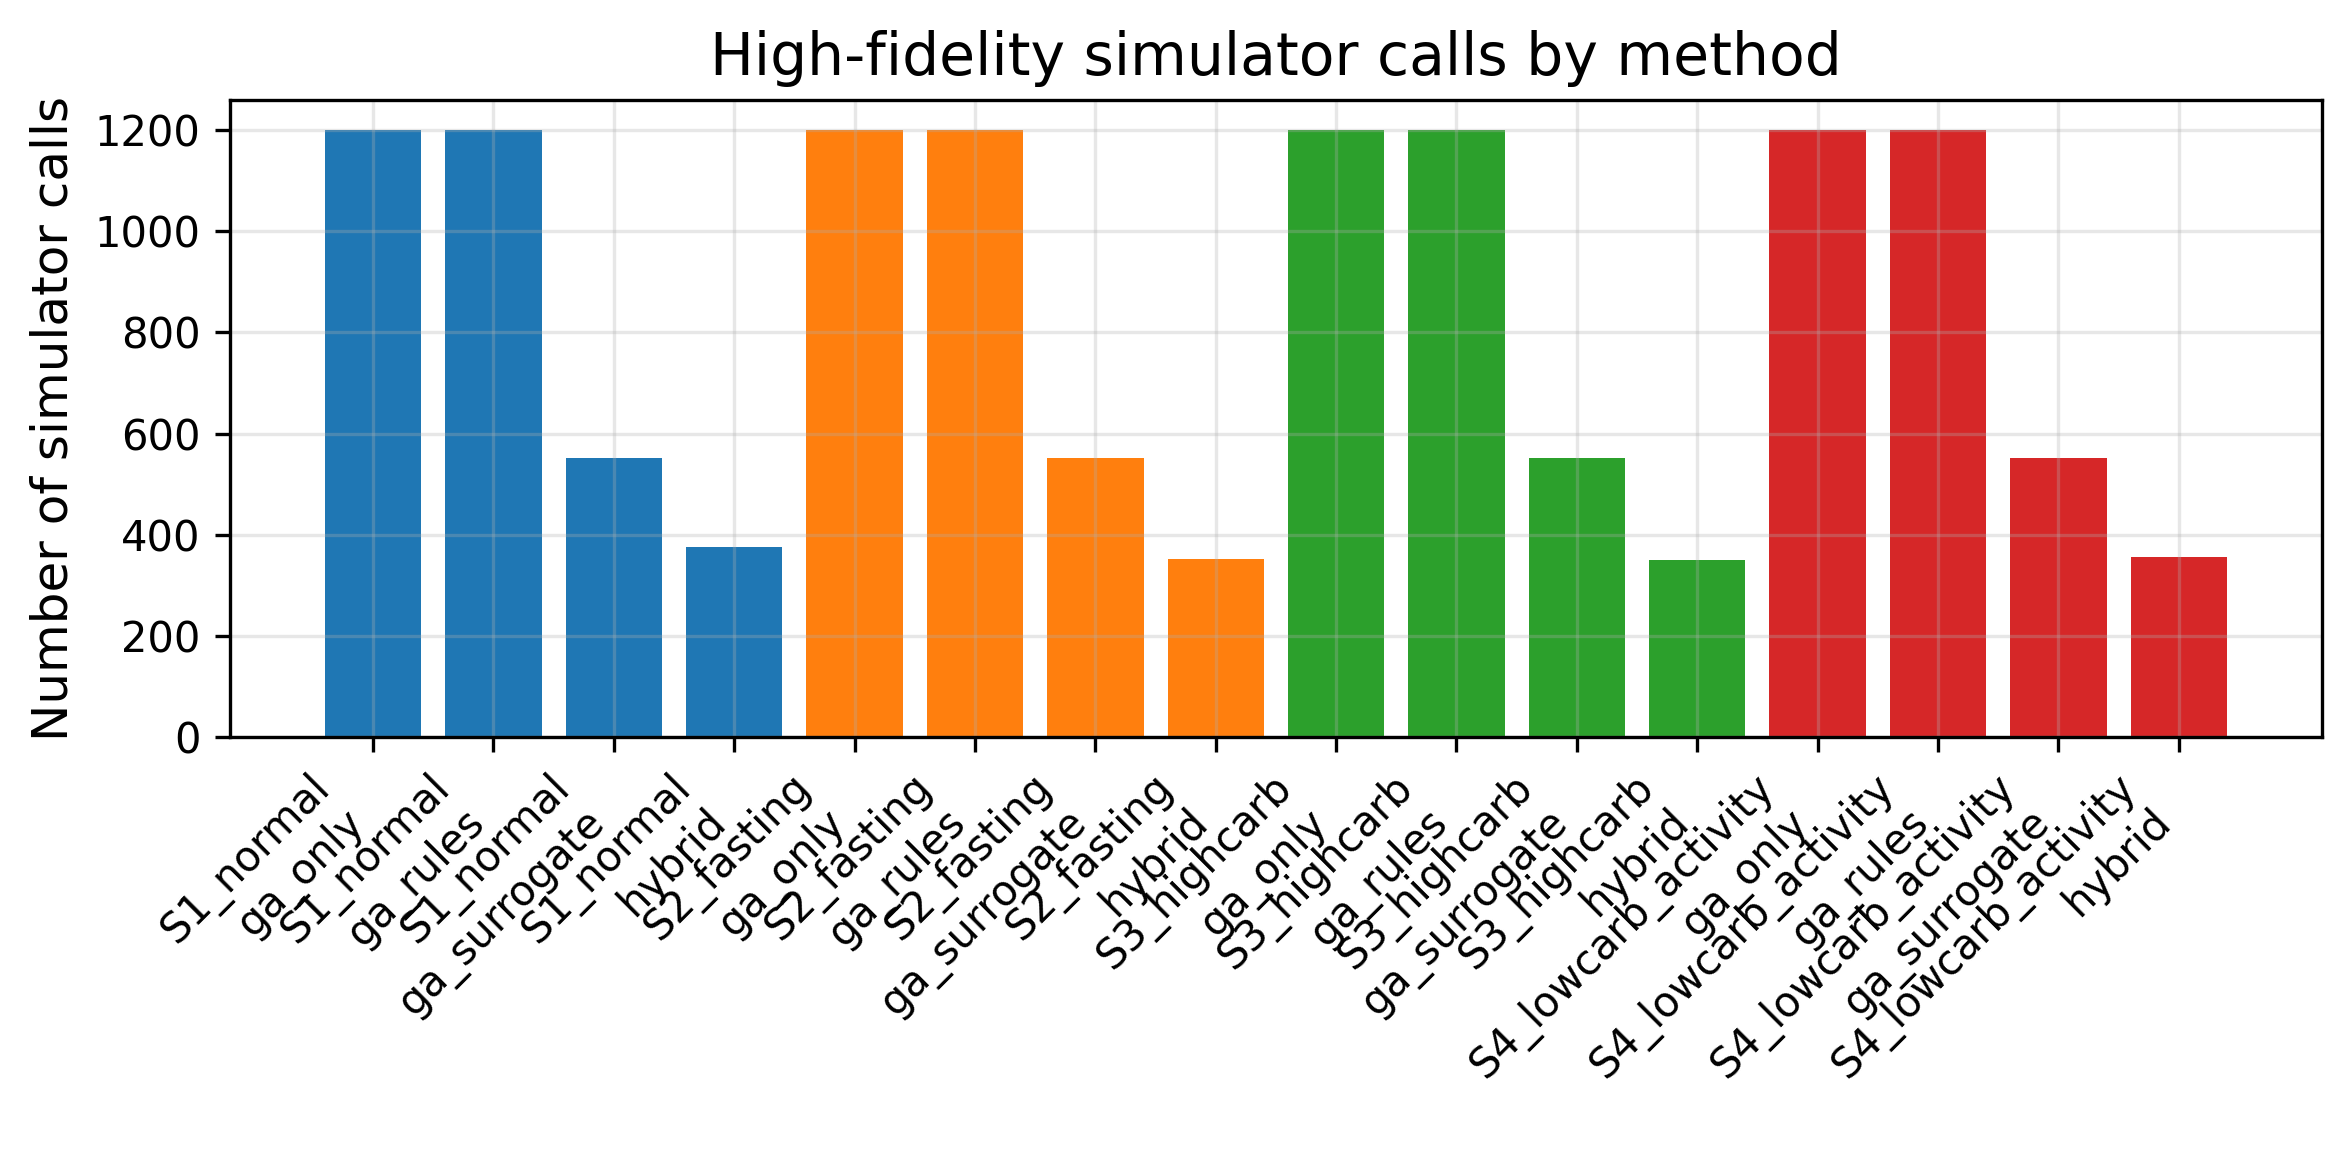

In [ ]:
#5. Figure : nombre de simulations
plt.figure(figsize=(8, 4))

for scenario in df2["Scenario"].unique():
    sub = df2[df2["Scenario"] == scenario]
    plt.bar(
        [f"{scenario}\n{m}" for m in sub["Method"]],
        sub["SimCalls"]
    )

plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of simulator calls")
plt.title("High-fidelity simulator calls by method")
plt.tight_layout()
plt.savefig("figures/sim_calls_comparison.pdf", bbox_inches="tight")
plt.show()